In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats

# Settings
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")
pd.set_option("display.max_columns", None)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import numpy as np

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    SGDRegressor
)

from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score, mean_squared_error


In [2]:
df = pd.read_csv("synthetic_health_data.csv")

df.head()


,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
0,45.960570,31.996777,5,55.403270,7.300359,0,2.834707,70.542122
1,38.340828,29.623168,6,41.838357,7.012419,1,7.199517,57.244637
2,47.772262,25.298152,5,76.904948,6.028641,1,4.097944,96.333722
3,58.276358,21.765316,2,49.756767,5.802714,1,3.649377,61.321783
4,37.190160,28.491117,2,44.218737,7.912548,0,2.839795,67.175894


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   float64
 1   BMI                  1000 non-null   float64
 2   Exercise_Frequency   1000 non-null   int64  
 3   Diet_Quality         1000 non-null   float64
 4   Sleep_Hours          1000 non-null   float64
 5   Smoking_Status       1000 non-null   int64  
 6   Alcohol_Consumption  1000 non-null   float64
 7   Health_Score         1000 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 62.6 KB


In [4]:
df.describe()


,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.231985,25.354181,2.888000,69.952977,6.973135,0.499000,3.079377,85.479947
std,11.750591,4.987272,1.995354,14.972061,1.517218,0.500249,2.084564,13.633845
min,1.104792,10.298057,0.000000,19.907497,2.431107,0.000000,-3.592506,29.106017
25%,32.228916,21.968792,1.000000,59.945481,5.903351,0.000000,1.644111,76.430819
50%,40.303607,25.315386,3.000000,69.975151,6.990847,0.000000,3.064261,87.498996
75%,47.775327,28.644411,5.000000,80.527839,8.054595,1.000000,4.489293,99.762644
max,86.232778,40.965538,6.000000,110.265186,11.638962,1.000000,11.105100,100.000000


In [5]:
# Missing values
df.isnull().sum()


,0
Age,0
BMI,0
Exercise_Frequency,0
Diet_Quality,0
Sleep_Hours,0
Smoking_Status,0
Alcohol_Consumption,0
Health_Score,0


In [6]:
# Duplicates
df.duplicated().sum()


np.int64(0)

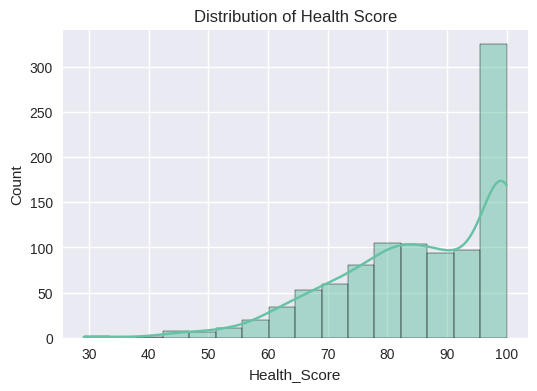

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df["Health_Score"], kde=True)
plt.title("Distribution of Health Score")
plt.show()


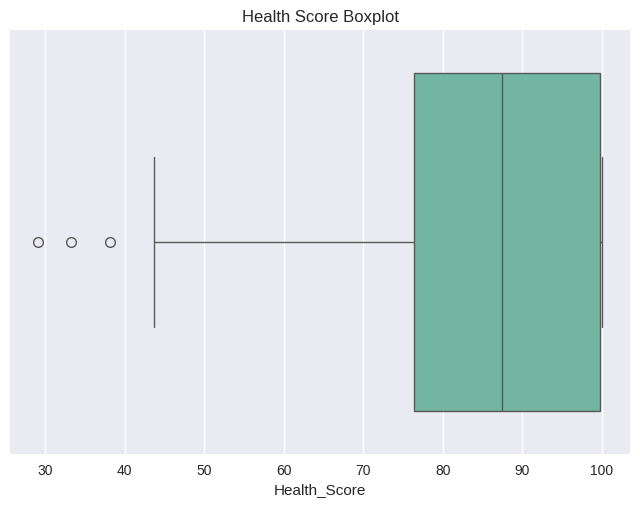

In [8]:
sns.boxplot(x=df["Health_Score"])
plt.title("Health Score Boxplot")
plt.show()


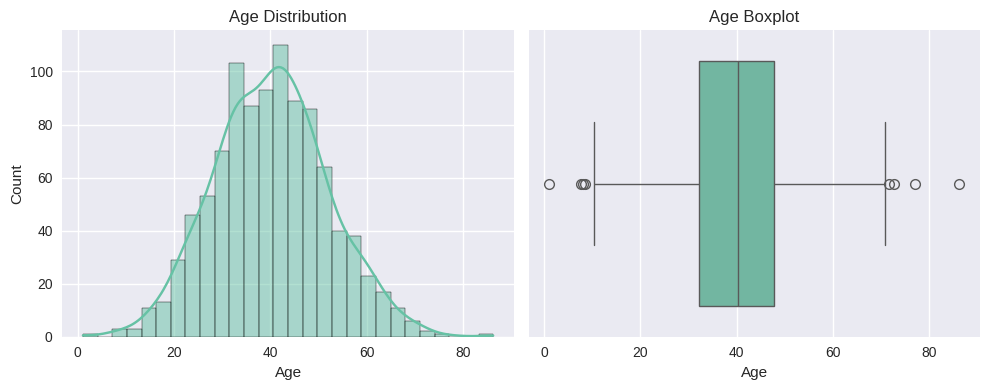

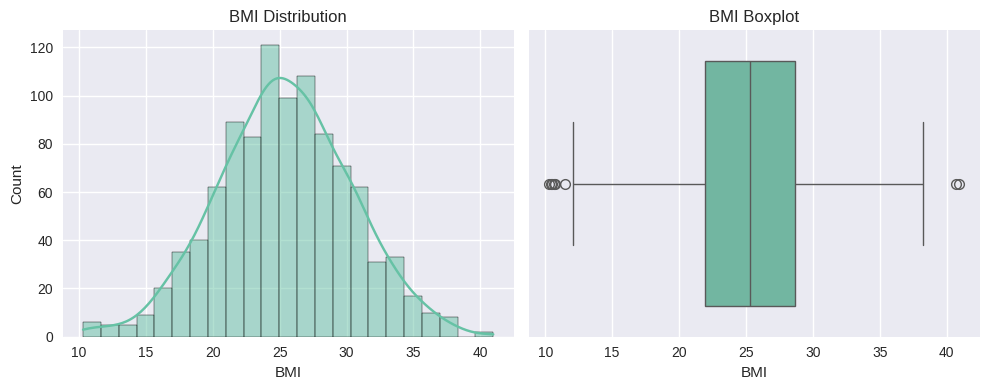

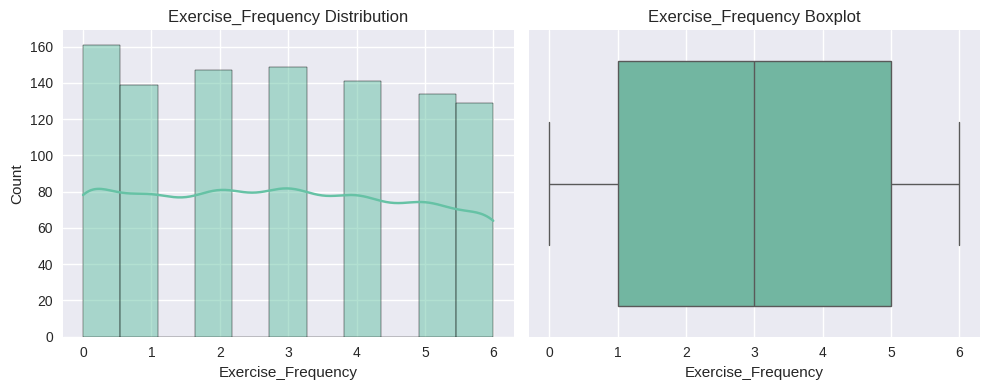

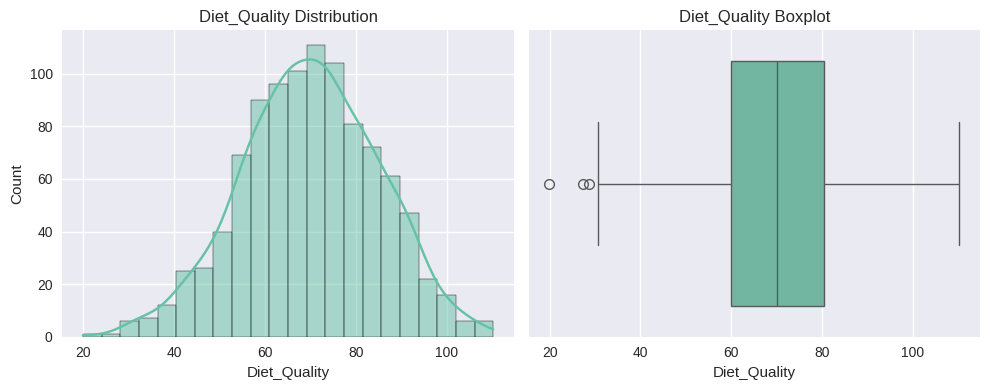

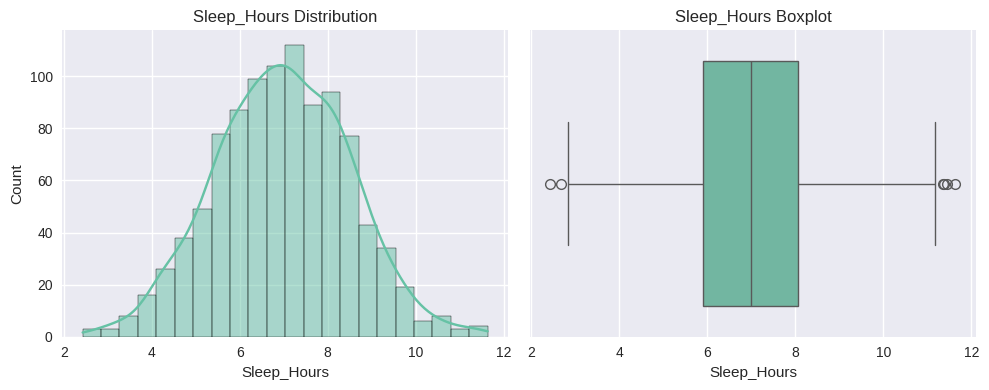

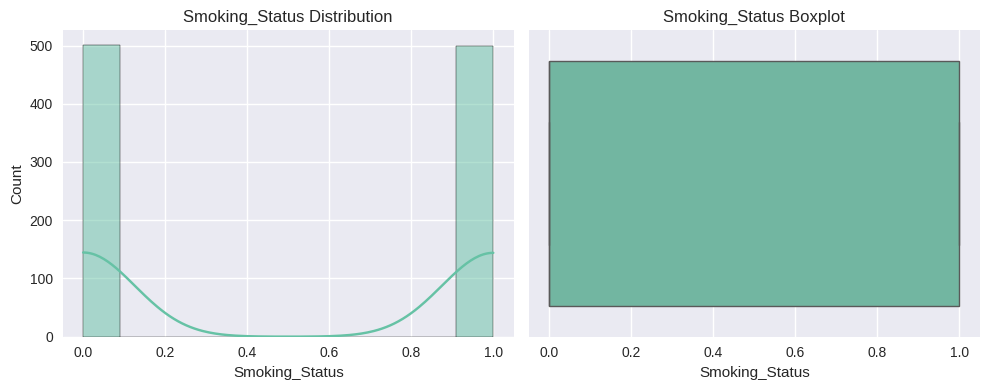

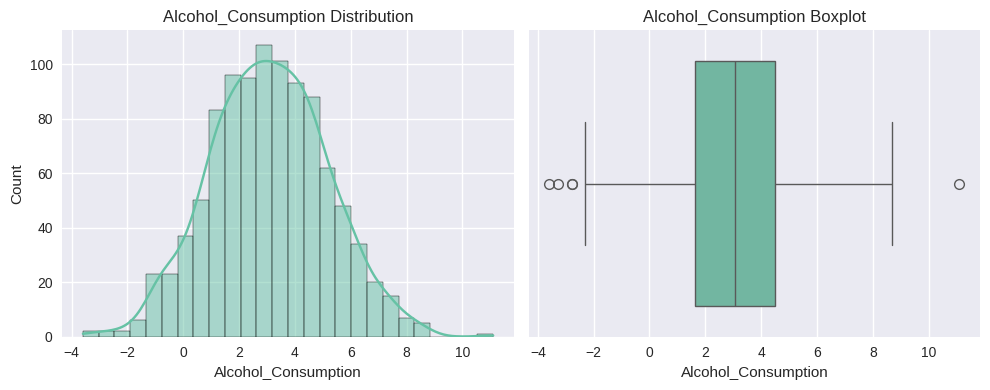

In [9]:
numeric_features = df.drop(columns=["Health_Score"]).columns

for col in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(10,4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Distribution")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} Boxplot")

    plt.tight_layout()
    plt.show()


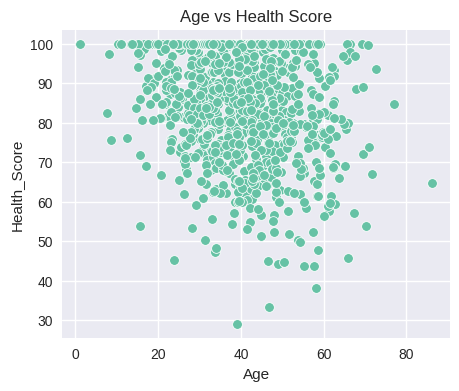

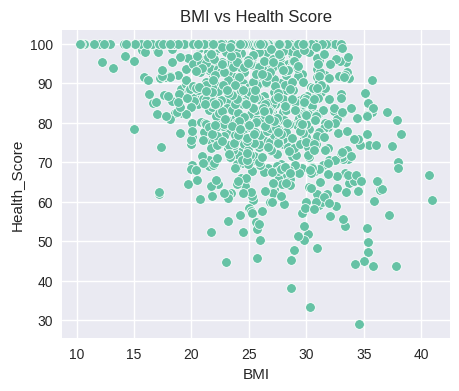

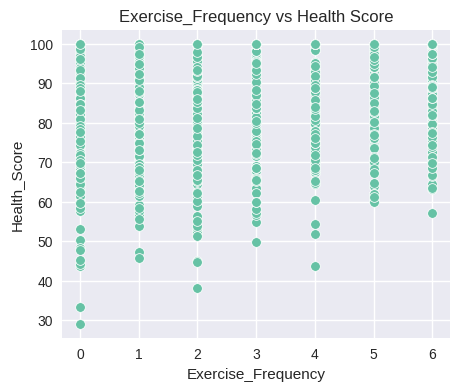

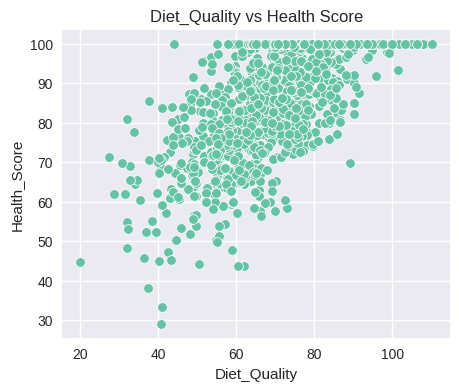

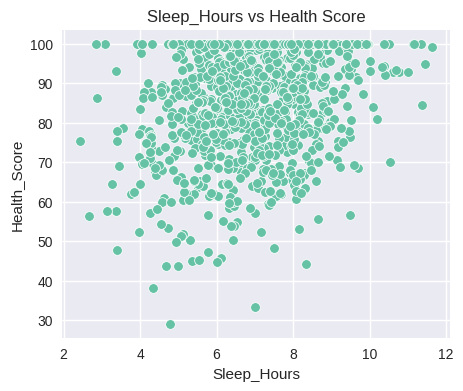

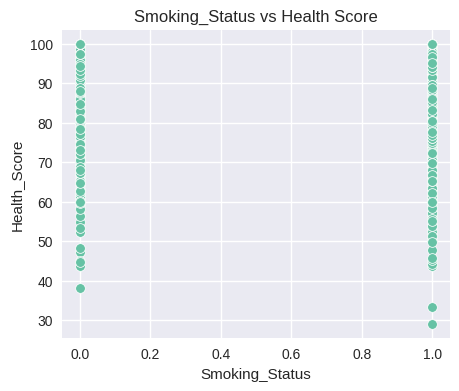

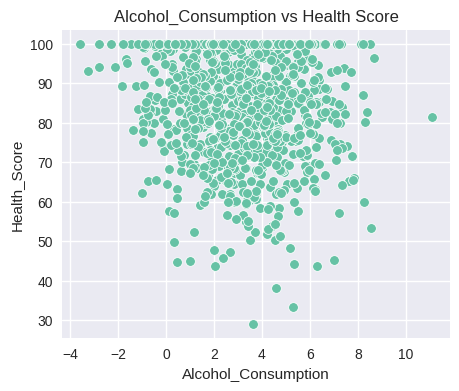

In [10]:
for col in numeric_features:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[col], y=df["Health_Score"])
    plt.title(f"{col} vs Health Score")
    plt.show()


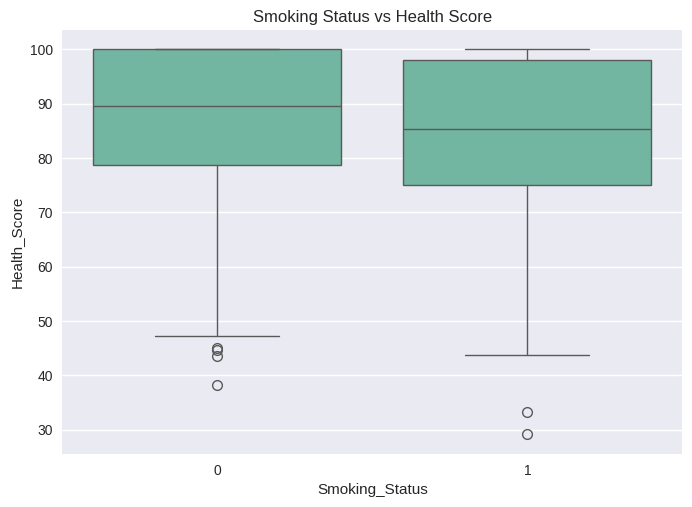

In [11]:
sns.boxplot(
    x=df["Smoking_Status"],
    y=df["Health_Score"]
)
plt.title("Smoking Status vs Health Score")
plt.show()


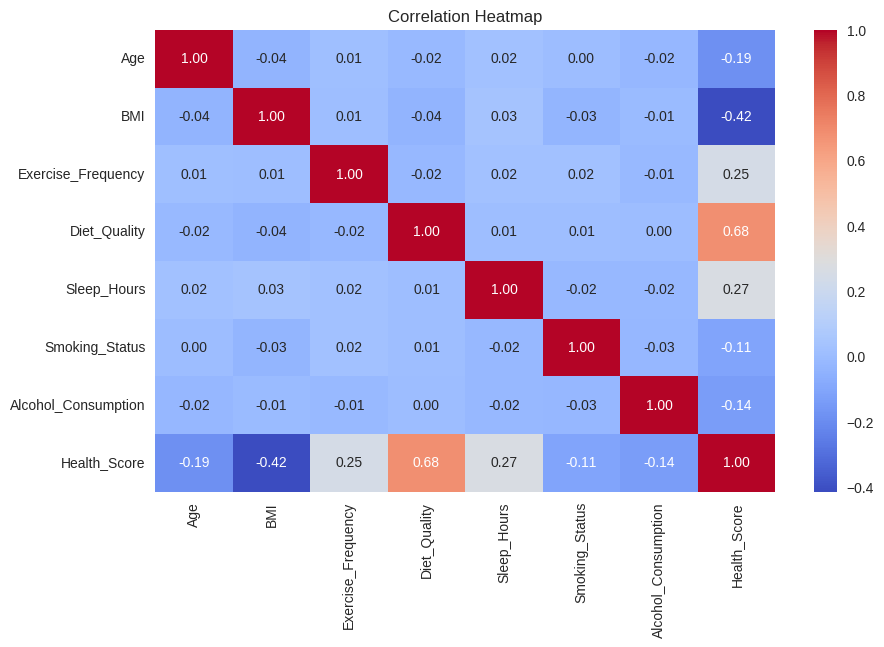

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()


In [13]:
df.skew().sort_values(ascending=False)


,0
Age,0.116976
Exercise_Frequency,0.054015
Alcohol_Consumption,0.045166
Sleep_Hours,0.010220
Smoking_Status,0.004006
BMI,-0.049396
Diet_Quality,-0.109471
Health_Score,-0.811165


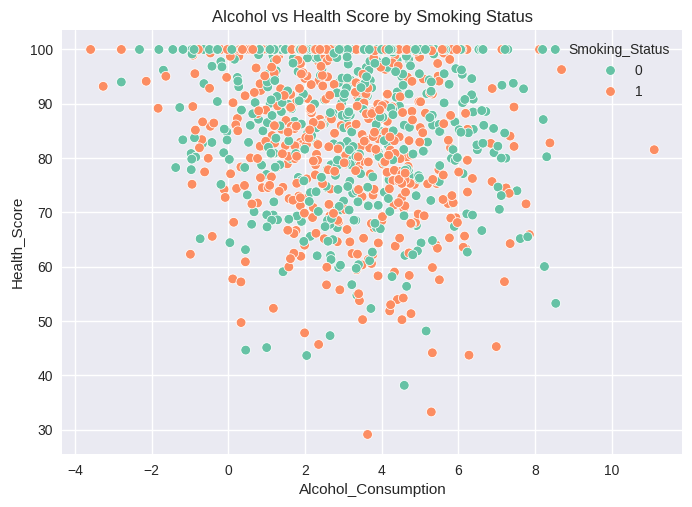

In [14]:
sns.scatterplot(
    x="Alcohol_Consumption",
    y="Health_Score",
    hue="Smoking_Status",
    data=df
)
plt.title("Alcohol vs Health Score by Smoking Status")
plt.show()


In [15]:
df_clean = df.copy()

# Fix Diet_Quality range
df_clean["Diet_Quality"] = df_clean["Diet_Quality"].clip(0, 100)

# Fix Alcohol negative values
df_clean["Alcohol_Consumption"] = df_clean["Alcohol_Consumption"].clip(lower=0)

df_clean.describe()


,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.231985,25.354181,2.888000,69.879123,6.973135,0.499000,3.141149,85.479947
std,11.750591,4.987272,1.995354,14.807154,1.517218,0.500249,1.966586,13.633845
min,1.104792,10.298057,0.000000,19.907497,2.431107,0.000000,0.000000,29.106017
25%,32.228916,21.968792,1.000000,59.945481,5.903351,0.000000,1.644111,76.430819
50%,40.303607,25.315386,3.000000,69.975151,6.990847,0.000000,3.064261,87.498996
75%,47.775327,28.644411,5.000000,80.527839,8.054595,1.000000,4.489293,99.762644
max,86.232778,40.965538,6.000000,100.000000,11.638962,1.000000,11.105100,100.000000


In [17]:
numeric_cols = [
    "Age", "BMI", "Exercise_Frequency",
    "Diet_Quality", "Sleep_Hours",
    "Alcohol_Consumption"
]

outlier_rows = detect_outliers_iqr(df_clean, numeric_cols)

print("Number of outlier rows:", len(outlier_rows))


Number of outlier rows: 26


In [18]:
df_outliers = df_clean.loc[outlier_rows]
df_outliers


,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
641,60.028258,32.061103,2,66.244020,2.662251,0,4.648460,56.386690
262,1.104792,27.693780,1,66.930674,7.193401,0,1.976643,100.000000
646,7.637360,24.064279,3,53.206664,5.705448,0,6.480529,82.418033
902,40.344938,30.865623,5,69.982798,11.638962,0,2.754476,99.290246
19,23.052356,27.120830,1,86.114014,6.247952,1,11.105100,81.539122
919,42.329080,22.639547,0,80.955433,2.431107,1,4.522996,75.334310
539,33.077298,10.638689,4,72.526029,5.571347,0,5.087692,100.000000
668,8.188362,29.203100,6,79.811584,5.812923,1,1.879536,97.376695
797,48.178008,21.019871,5,63.712571,11.344778,0,2.959176,100.000000
932,22.623833,22.673448,1,53.633064,11.444663,0,3.604154,94.976964


In [19]:
df_clean = df.copy()
print("Before:", df_clean.shape)

df_clean = df_clean.drop(index=outlier_rows)

print("After:", df_clean.shape)


# Fix logical issues
df_clean["Diet_Quality"] = df_clean["Diet_Quality"].clip(0, 100)
df_clean["Alcohol_Consumption"] = df_clean["Alcohol_Consumption"].clip(lower=0)


Before: (1000, 8)
After: (974, 8)


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Target
y = df_clean["Health_Score"]
X = df_clean.drop(columns=["Health_Score"])

# Create bins for stratification
y_bins = pd.cut(
    y,
    bins=[0, 40, 70, 100],
    labels=["low", "mid", "high"]
)

print(y_bins.value_counts())
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y_bins
)



Health_Score
high    833
mid     138
low       3
Name: count, dtype: int64


In [21]:
print("Train distribution:")
print(pd.cut(y_train, bins=[0,40,70,100]).value_counts(normalize=True))

print("\nTest distribution:")
print(pd.cut(y_test, bins=[0,40,70,100]).value_counts(normalize=True))


import numpy as np

X_train = X_train.copy()
X_test  = X_test.copy()

X_train["Alcohol_Consumption"] = np.log1p(X_train["Alcohol_Consumption"])
X_test["Alcohol_Consumption"]  = np.log1p(X_test["Alcohol_Consumption"])


Train distribution:
Health_Score
(70, 100]    0.854942
(40, 70]     0.141207
(0, 40]      0.003851
Name: proportion, dtype: float64

Test distribution:
Health_Score
(70, 100]    0.85641
(40, 70]     0.14359
(0, 40]      0.00000
Name: proportion, dtype: float64


In [22]:
numeric_cols = [
    "Age", "BMI", "Exercise_Frequency",
    "Diet_Quality", "Sleep_Hours",
    "Alcohol_Consumption"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])


In [23]:
def evaluate(model, Xtr, Xte, name):
    model.fit(Xtr, y_train)

    preds = model.predict(Xte)
    preds = np.clip(preds, 0, 100)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"{name:<30} | R2: {r2:.4f} | RMSE: {rmse:.2f}")


In [33]:
results = []
model = LinearRegression()
model.fit(X_train_scaled, y_train)

train_preds = np.clip(model.predict(X_train_scaled), 0, 100)
test_preds  = np.clip(model.predict(X_test_scaled), 0, 100)

results.append({
    "Model": "Linear",
    "Params": "default",
    "R2_Train": r2_score(y_train, train_preds),
    "RMSE_Train": np.sqrt(mean_squared_error(y_train, train_preds)),
    "R2_Test": r2_score(y_test, test_preds),
    "RMSE_Test": np.sqrt(mean_squared_error(y_test, test_preds)),
})


In [34]:
alphas = [0.001, 0.01, 0.1, 1, 10]

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)

    train_preds = np.clip(model.predict(X_train_scaled), 0, 100)
    test_preds  = np.clip(model.predict(X_test_scaled), 0, 100)

    results.append({
        "Model": "Ridge",
        "Params": f"alpha={a}",
        "R2_Train": r2_score(y_train, train_preds),
        "RMSE_Train": np.sqrt(mean_squared_error(y_train, train_preds)),
        "R2_Test": r2_score(y_test, test_preds),
        "RMSE_Test": np.sqrt(mean_squared_error(y_test, test_preds)),
    })


In [35]:
alphas = [0.01, 0.1, 1]

for a in alphas:
    model = Lasso(alpha=a, max_iter=5000)
    model.fit(X_train_scaled, y_train)

    train_preds = np.clip(model.predict(X_train_scaled), 0, 100)
    test_preds  = np.clip(model.predict(X_test_scaled), 0, 100)

    results.append({
        "Model": "Lasso",
        "Params": f"alpha={a}",
        "R2_Train": r2_score(y_train, train_preds),
        "RMSE_Train": np.sqrt(mean_squared_error(y_train, train_preds)),
        "R2_Test": r2_score(y_test, test_preds),
        "RMSE_Test": np.sqrt(mean_squared_error(y_test, test_preds)),
    })


In [36]:
degrees = [2, 3]
alphas  = [0.1, 1, 1.5, 10]

for d in degrees:
    for a in alphas:
        model = KernelRidge(
            kernel="polynomial",
            degree=d,
            alpha=a,
            coef0=2
        )
        model.fit(X_train_scaled, y_train)

        train_preds = np.clip(model.predict(X_train_scaled), 0, 100)
        test_preds  = np.clip(model.predict(X_test_scaled), 0, 100)

        results.append({
            "Model": "KernelRidge",
            "Params": f"deg={d}, alpha={a}",
            "R2_Train": r2_score(y_train, train_preds),
            "RMSE_Train": np.sqrt(mean_squared_error(y_train, train_preds)),
            "R2_Test": r2_score(y_test, test_preds),
            "RMSE_Test": np.sqrt(mean_squared_error(y_test, test_preds)),
        })


In [37]:
etas   = [0.001, 0.01, 0.05]
alphas = [0.0001, 0.001]

for eta in etas:
    for a in alphas:
        model = SGDRegressor(
            loss="squared_error",
            learning_rate="adaptive",
            eta0=eta,
            alpha=a,
            max_iter=5000,
            shuffle=True,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            tol=1e-4,
            random_state=42
        )

        model.fit(X_train_scaled, y_train)

        train_preds = np.clip(model.predict(X_train_scaled), 0, 100)
        test_preds  = np.clip(model.predict(X_test_scaled), 0, 100)

        results.append({
            "Model": "SGD",
            "Params": f"eta={eta}, alpha={a}",
            "R2_Train": r2_score(y_train, train_preds),
            "RMSE_Train": np.sqrt(mean_squared_error(y_train, train_preds)),
            "R2_Test": r2_score(y_test, test_preds),
            "RMSE_Test": np.sqrt(mean_squared_error(y_test, test_preds)),
        })


In [38]:
results_df = pd.DataFrame(results)

results_df["Overfitting_Gap"] = (
    results_df["R2_Train"] - results_df["R2_Test"]
)

results_df = results_df.sort_values(
    by=["R2_Test", "RMSE_Test"],
    ascending=[False, True]
)

results_df


,Model,Params,R2_Train,RMSE_Train,R2_Test,RMSE_Test,Overfitting_Gap
16,KernelRidge,"deg=3, alpha=10",0.912134,4.050925,0.878297,4.520080,0.033837
15,KernelRidge,"deg=3, alpha=1.5",0.919478,3.877945,0.874643,4.587431,0.044835
11,KernelRidge,"deg=2, alpha=1.5",0.902854,4.259491,0.872508,4.626339,0.030346
14,KernelRidge,"deg=3, alpha=1",0.920087,3.863258,0.872507,4.626347,0.047580
10,KernelRidge,"deg=2, alpha=1",0.902879,4.258947,0.872359,4.629028,0.030519
9,KernelRidge,"deg=2, alpha=0.1",0.902752,4.261710,0.871854,4.638185,0.030899
12,KernelRidge,"deg=2, alpha=10",0.897230,4.381053,0.868343,4.701286,0.028886
13,KernelRidge,"deg=3, alpha=0.1",0.921087,3.839014,0.864669,4.766439,0.056418
0,Linear,default,0.875496,4.822094,0.857956,4.883226,0.017540
1,Ridge,alpha=0.001,0.875496,4.822099,0.857956,4.883229,0.017540


In [39]:
best_row = results_df.iloc[0]
best_row


,16
Model,KernelRidge
Params,"deg=3, alpha=10"
R2_Train,0.912134
RMSE_Train,4.050925
R2_Test,0.878297
RMSE_Test,4.52008
Overfitting_Gap,0.033837


In [40]:
final_model = KernelRidge(
    kernel="polynomial",
    degree=3,
    alpha=10,
    coef0=2
)

final_model.fit(X_train_scaled, y_train)


KernelRidge(alpha=10, coef0=2, kernel='polynomial')

In [41]:
import joblib

joblib.dump(final_model, "health_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']